- Group Name : PC
- Members :
    - Balasuriya B.D.S.K 220056X,
    - Dissanayake D.M.A.K 220135N,
    - Samaratunge O.V. 220555C,
    - Kodisinghe R.R. 220332K

State of the art models can be seen from the below repository.
[Github Repository](https://github.com/OsaVS/cnn-realwaste)

# Waste Material Classification using CNN

This notebook implements a Convolutional Neural Network to classify waste materials into 9 categories: Cardboard, Food Organics, Glass, Metal, Miscellaneous Trash, Paper, Plastic, Textile Trash, and Vegetation.


### Import Libraries

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import models
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## GPU Memory Management

Clear CUDA cache and configure memory settings for optimal performance.

In [5]:
# Clear CUDA cache to free up memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared")
    
    # Get memory info
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"GPU Memory Allocated: {allocated:.2f} GB")
    print(f"GPU Memory Reserved: {reserved:.2f} GB")
    
    # Enable memory efficient settings
    torch.backends.cudnn.benchmark = True  # Find optimal algorithms
    torch.backends.cuda.matmul.allow_tf32 = True  # Use TF32 for faster computation
    
    print("\nMemory-efficient settings enabled")
else:
    print("CUDA not available, using CPU")

CUDA cache cleared
GPU Memory Allocated: 0.00 GB
GPU Memory Reserved: 0.00 GB

Memory-efficient settings enabled


## Dataset Configuration
- Resize the 524x524 to 224x224
- Set the batch size to 32. The number of data samples (images) that will be processed simultaneously during one forward/backward pass of the model
- Number of distinct classes for which the classification should be done is set to 9.
- Total number of epoch count is set to 20.

In [6]:
# Dataset parameters
IMAGE_SIZE = 224 # Updated image size
BATCH_SIZE = 32
NUM_CLASSES = 9
NUM_EPOCHS = 50

# Class names and their counts
CLASS_NAMES = [
    'Cardboard',         # 461
    'Food Organics',     # 411
    'Glass',             # 420
    'Metal',             # 790
    'Miscellaneous Trash',     # 495
    'Paper',             # 500
    'Plastic',           # 921
    'Textile Trash',           # 318
    'Vegetation'         # 436
]

DATA_DIR = '/home/ravindu/Documents/Projects/cnn-realwaste/realwaste/RealWaste'

## Dataset class

In [7]:
class WasteDataset(Dataset):
    """Fixed Custom Dataset for loading waste material images"""

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for class_idx, class_name in enumerate(CLASS_NAMES):
            class_dir = self.root_dir / class_name
            if class_dir.exists():
                image_files = sorted(class_dir.glob('*.*'))

                for img_path in image_files:
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                        self.images.append(str(img_path))
                        self.labels.append(class_idx)
            else:
                print(f"Warning: Directory not found: {class_dir}")

        print(f"Loaded {len(self.images)} images from {len(CLASS_NAMES)} classes")

        if len(self.images) == 0:
            raise RuntimeError(f"No images found in {root_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return black image if error
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, label

## Calculating normalization values
- Calculate μ and σ for each channel (R, G, B) of the specific training set using 1000 images from that dataset.

In [8]:
def calculate_mean_std(dataset_path, image_size=224, sample_size=None):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])

    temp_dataset = WasteDataset(root_dir=dataset_path, transform=transform)

    if sample_size and sample_size < len(temp_dataset):
        indices = np.random.choice(len(temp_dataset), sample_size, replace=False)
        temp_dataset = torch.utils.data.Subset(temp_dataset, indices)

    loader = DataLoader(temp_dataset, batch_size=32, shuffle=False, num_workers=4)

    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0

    for images, _ in loader:
        channels_sum += torch.mean(images, dim=[0, 2, 3]) * images.size(0)
        channels_squared_sum += torch.mean(images ** 2, dim=[0, 2, 3]) * images.size(0)
        num_pixels += images.size(0)

    mean = channels_sum / num_pixels
    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)

    print(f"Dataset Mean (R, G, B): [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]")
    print(f"Dataset Std (R, G, B): [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]")

    return mean.tolist(), std.tolist()

dataset_mean, dataset_std = calculate_mean_std(DATA_DIR, IMAGE_SIZE, sample_size=1000)

Loaded 4752 images from 9 classes
Dataset Mean (R, G, B): [0.5959, 0.6181, 0.6327]
Dataset Std (R, G, B): [0.1614, 0.1624, 0.1879]


## Data augmentation and pre-processing
### Training dataset
- Resizing
- Random horizontal flip
- Random rotation
- Color jitter (Randomly alter the brightness, contrast, and saturation)
- Convert the image from a PIL Image to a PyTorch Tensor and automatically scale pixel values from [0,255] to the floating-point range of [0.0,1.0]
- Standardize the Tensor data

### Validation data set
- Resizing
- Tensor conversion
- Normalization


In [9]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7,1.0), ratio=(0.9,1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.2), ratio=(0.3,3.3))
])

val_test_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE*1.15)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])


## Load and split data set
- Load the full data set and split it into 70% training, 15% validation and 15% testing.
- Create the necessary data loaders

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from torch.utils.data import Subset

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

print(f"\nSplit ratios:")
print(f"  Training:   {train_ratio*100:.0f}%")
print(f"  Validation: {val_ratio*100:.0f}%")
print(f"  Testing:    {test_ratio*100:.0f}%")

full_dataset = WasteDataset(root_dir=DATA_DIR, transform=None)

labels = np.array([full_dataset[i][1] for i in range(len(full_dataset))])

unique, counts = np.unique(labels, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {CLASS_NAMES[label_idx]:20s}: {count:4d} images ({count/len(labels)*100:.1f}%)")

sss1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=(val_ratio + test_ratio),
    random_state=42
)
train_idx, temp_idx = next(sss1.split(np.arange(len(labels)), labels))

temp_labels = labels[temp_idx]
relative_test_size = test_ratio / (val_ratio + test_ratio)

sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=relative_test_size,
    random_state=42
)
val_idx_rel, test_idx_rel = next(sss2.split(np.arange(len(temp_idx)), temp_labels))

val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

def print_split_distribution(indices, split_name):
    split_labels = labels[indices]
    print(f"\n{split_name} distribution:")
    unique, counts = np.unique(split_labels, return_counts=True)
    for label_idx, count in zip(unique, counts):
        percentage = count / len(split_labels) * 100
        print(f"  {CLASS_NAMES[label_idx]:20s}: {count:4d} ({percentage:5.1f}%)")

print_split_distribution(train_idx, "TRAINING")
print_split_distribution(val_idx, "VALIDATION")
print_split_distribution(test_idx, "TESTING")

train_dataset_full = WasteDataset(root_dir=DATA_DIR, transform=train_transform)
val_dataset_full = WasteDataset(root_dir=DATA_DIR, transform=val_test_transform)
test_dataset_full = WasteDataset(root_dir=DATA_DIR, transform=val_test_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)
test_dataset = Subset(test_dataset_full, test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

# Test one batch
images, batch_labels = next(iter(train_loader))

print("DATASET LOADING COMPLETE!")



Split ratios:
  Training:   70%
  Validation: 15%
  Testing:    15%
Loaded 4752 images from 9 classes
  Cardboard           :  461 images (9.7%)
  Food Organics       :  411 images (8.6%)
  Glass               :  420 images (8.8%)
  Metal               :  790 images (16.6%)
  Miscellaneous Trash :  495 images (10.4%)
  Paper               :  500 images (10.5%)
  Plastic             :  921 images (19.4%)
  Textile Trash       :  318 images (6.7%)
  Vegetation          :  436 images (9.2%)

TRAINING distribution:
  Cardboard           :  323 (  9.7%)
  Food Organics       :  288 (  8.7%)
  Glass               :  294 (  8.8%)
  Metal               :  553 ( 16.6%)
  Miscellaneous Trash :  346 ( 10.4%)
  Paper               :  350 ( 10.5%)
  Plastic             :  645 ( 19.4%)
  Textile Trash       :  222 (  6.7%)
  Vegetation          :  305 (  9.2%)

VALIDATION distribution:
  Cardboard           :   69 (  9.7%)
  Food Organics       :   61 (  8.6%)
  Glass               :   63 (  8.8%)


In [11]:
from collections import Counter

print("COMPUTING CLASS WEIGHTS FOR IMBALANCED DATASET")

# Get training labels
train_labels = labels[train_idx].tolist()
class_counts = Counter(train_labels)

# Compute inverse frequency weights
total_train = len(train_labels)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

for i, (name, weight) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f"  {name:20s}: {weight:.3f} (count: {class_counts[i]:3d})")

# Use weighted loss with label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)


COMPUTING CLASS WEIGHTS FOR IMBALANCED DATASET
  Cardboard           : 1.144 (count: 323)
  Food Organics       : 1.283 (count: 288)
  Glass               : 1.257 (count: 294)
  Metal               : 0.668 (count: 553)
  Miscellaneous Trash : 1.068 (count: 346)
  Paper               : 1.056 (count: 350)
  Plastic             : 0.573 (count: 645)
  Textile Trash       : 1.665 (count: 222)
  Vegetation          : 1.212 (count: 305)


## CNN Architecture Overview

### **Input**
- **RGB image** of size **3 × 224 × 224**

---

## **Convolutional Block 1**
- **Conv2D:** 32 filters, 3×3 kernel, padding=1  
- **BatchNorm2D**  
- **ReLU** activation  
- **MaxPool2D:** 2×2, stride=2  
**Output:** 32 × 112 × 112  

---

## **Convolutional Block 2**
- **Conv2D:** 64 filters, 3×3 kernel, padding=1  
- **BatchNorm2D**  
- **ReLU** activation  
- **MaxPool2D:** 2×2, stride=2  
**Output:** 64 × 56 × 56  

---

## **Convolutional Block 3**
- **Conv2D:** 128 filters, 3×3 kernel, padding=1  
- **BatchNorm2D**  
- **ReLU** activation  
- **MaxPool2D:** 2×2, stride=2  
**Output:** 128 × 28 × 28  

---

## **Convolutional Block 4**
- **Conv2D:** 256 filters, 3×3 kernel, padding=1  
- **BatchNorm2D**  
- **ReLU** activation  
- **MaxPool2D:** 2×2, stride=2  
**Output:** 256 × 14 × 14  

---

## **Flatten Layer**
- Converts feature maps to vector  
- **50,176 features**

---

## **Fully Connected Block 1**
- **Linear:** 50,176 → 256  
- **BatchNorm1D**  
- **ReLU**  
- **Dropout:** 15%

---

## **Fully Connected Block 2**
- **Linear:** 256 → 128  
- **BatchNorm1D**  
- **ReLU**  
- **Dropout:** 7.5%

---

## **Output Layer**
- **Linear:** 128 → 9 classes  
- Softmax applied by the loss function (e.g., `CrossEntropyLoss`)

---


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("="*70)
print("BUILDING SIMPLIFIED WASTENET ARCHITECTURE")
print("="*70)

class WasteNetSimple(nn.Module):
    """Simplified CNN for Waste Classification with Extended Layers"""
    
    def __init__(self, num_classes=9, x1=32, m1=3, x2=64, m2=3, x3=128, dropout_rate=0.5):
        """
        Args:
            num_classes (int): Number of output classes (K)
            x1 (int): Number of filters in first conv layer
            m1 (int): Kernel size for first conv layer
            x2 (int): Number of filters in second conv layer
            m2 (int): Kernel size for second conv layer
            x3 (int): Number of units in fully connected layer
            dropout_rate (float): Dropout rate (d)
        """
        super(WasteNetSimple, self).__init__()
        
        print(f"\n🏗️  Building WasteNet-Simple Architecture...")
        print(f"   Conv1: {x1} filters, {m1}×{m1} kernel")
        print(f"   Conv2: {x2} filters, {m2}×{m2} kernel")
        print(f"   FC: {x3} units")
        print(f"   Dropout: {dropout_rate}")
        
        # First Convolutional Block
        self.conv1 = nn.Conv2d(3, x1, kernel_size=m1, padding=m1//2)
        self.bn1 = nn.BatchNorm2d(x1)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second Convolutional Block
        self.conv2 = nn.Conv2d(x1, x2, kernel_size=m2, padding=m2//2)
        self.bn2 = nn.BatchNorm2d(x2)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Additional Convolutional Blocks for Better Performance
        self.conv3 = nn.Conv2d(x2, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Calculate flattened size (assuming 224x224 input)
        # After 4 pooling layers: 224 -> 112 -> 56 -> 28 -> 14
        self.flatten_size = 256 * 14 * 14
        
        # Fully Connected Layers
        self.flatten = nn.Flatten()
        
        # First FC layer
        self.fc1 = nn.Linear(self.flatten_size, x3)
        self.bn_fc1 = nn.BatchNorm1d(x3)
        self.relu_fc1 = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # Additional FC layer for better performance
        self.fc2 = nn.Linear(x3, x3 // 2)
        self.bn_fc2 = nn.BatchNorm1d(x3 // 2)
        self.relu_fc2 = nn.ReLU(inplace=True)
        self.dropout2 = nn.Dropout(dropout_rate * 0.5)
        
        # Output layer (K classes with softmax)
        self.fc_out = nn.Linear(x3 // 2, num_classes)
        
        # Initialize weights
        self._initialize_weights()
        
        print("✅ Architecture built successfully!")
    
    def _initialize_weights(self):
        """Initialize weights using He initialization"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                if m.weight is not None:
                    nn.init.constant_(m.weight, 1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # First Conv Block
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Second Conv Block
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Third Conv Block (additional)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        # Fourth Conv Block (additional)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool4(x)
        
        # Flatten
        x = self.flatten(x)
        
        # First FC layer with dropout
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu_fc1(x)
        x = self.dropout1(x)
        
        # Second FC layer with dropout (additional)
        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu_fc2(x)
        x = self.dropout2(x)
        
        # Output layer (softmax applied in loss function)
        x = self.fc_out(x)
        
        return x


# Clear previous model
if 'model' in globals():
    del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Create model with customizable parameters
# You can adjust these hyperparameters:
X1 = 32      # First conv filters
M1 = 3       # First conv kernel size
X2 = 64      # Second conv filters
M2 = 3       # Second conv kernel size
X3 = 256     # FC layer units
D = 0.15      # Dropout rate

model = WasteNetSimple(
    num_classes=NUM_CLASSES,
    x1=X1,
    m1=M1,
    x2=X2,
    m2=M2,
    x3=X3,
    dropout_rate=D
).to(device)

# Model statistics
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*70)
print("MODEL STATISTICS")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB")

BUILDING SIMPLIFIED WASTENET ARCHITECTURE

🏗️  Building WasteNet-Simple Architecture...
   Conv1: 32 filters, 3×3 kernel
   Conv2: 64 filters, 3×3 kernel
   FC: 256 units
   Dropout: 0.15
✅ Architecture built successfully!

MODEL STATISTICS
Total parameters: 13,269,513
Trainable parameters: 13,269,513
Model size: ~50.6 MB


## Loss function and Optimizer
- Loss function -> Cross entropy loss
- Optimizer -> Adaptive Moment Estimation with decoupled weight decay(ADAMW)
- Learning rate scheduler -> OneCycleLR scheduler

In [ ]:
print("CONFIGURING TRAINING COMPONENTS")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-5)

# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=1e-3,
#     momentum=0.9,       # Common value: 0.9
#     weight_decay=1e-5
# )


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,       # reduce!
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.2,     # start peak earlier
    div_factor=10,     # initial lr = max_lr / 10
    final_div_factor=1000,
    anneal_strategy='cos'
)

total_params = sum(p.numel() for p in model.parameters())


CONFIGURING TRAINING COMPONENTS


## Training Loop

In [50]:
# import torch
import time
import copy
# import matplotlib.pyplot as plt

print("="*70)
print("STARTING MODEL TRAINING")
print("="*70)

# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    """Train for one epoch with OneCycleLR support"""
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # OneCycleLR steps per batch - with safety check
        if scheduler.last_epoch < scheduler.total_steps:
            scheduler.step()
        
        # Calculate metrics
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()


# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================
NUM_EPOCHS = 20
SAVE_BEST_ONLY = True  # Only save when validation improves

# Initialize tracking
best_val_accuracy = 0.0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

training_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rates': []
}

# Verify scheduler setup
print(f"\nScheduler Configuration:")
print(f"  Total steps expected: {scheduler.total_steps}")
print(f"  Steps per epoch: {len(train_loader)}")
print(f"  Total epochs: {NUM_EPOCHS}")
print(f"  Calculated total: {len(train_loader) * NUM_EPOCHS}")

# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================
print("="*70)
print(f"Training for {NUM_EPOCHS} epochs with OneCycleLR scheduler")
print("="*70)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    training_history['learning_rates'].append(current_lr)
    
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | LR: {current_lr:.6f}")
    print(f"{'='*70}")

    # Training phase
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    
    # Validation phase
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Store history
    training_history['train_loss'].append(train_loss)
    training_history['train_acc'].append(train_acc)
    training_history['val_loss'].append(val_loss)
    training_history['val_acc'].append(val_acc)
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start
    
    # Display metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"Time: {epoch_time:.1f}s")
    
    # Check for overfitting
    acc_gap = val_acc - train_acc
    if acc_gap > 0.10:
        print(f"⚠️  Large accuracy gap detected: {acc_gap*100:.2f}%")
    
    # Save best model
    is_best = val_acc > best_val_accuracy
    
    if is_best:
        best_val_accuracy = val_acc
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f"✅ New best model! Val Acc: {best_val_accuracy*100:.2f}%")
        
        # Save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_accuracy,
            'best_val_loss': best_val_loss,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'training_history': training_history
        }, 'best_wastenet_model.pth')
    elif not SAVE_BEST_ONLY:
        # Save every epoch if SAVE_BEST_ONLY is False
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_accuracy,
            'val_loss': val_loss,
        }, f'checkpoint_epoch_{epoch+1}.pth')

# ============================================================================
# TRAINING COMPLETE
# ============================================================================
total_time = time.time() - start_time
print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"Total Time: {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"Best Val Accuracy: {best_val_accuracy*100:.2f}%")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total Epochs Trained: {len(training_history['train_loss'])}")
print("="*70)

# Load best model weights
model.load_state_dict(best_model_wts)
print("✅ Best model weights loaded")

STARTING MODEL TRAINING

Scheduler Configuration:
  Total steps expected: 2080
  Steps per epoch: 104
  Total epochs: 20
  Calculated total: 2080
Training for 20 epochs with OneCycleLR scheduler

Epoch 1/20 | LR: 0.000050


Train Loss: 1.0618 | Train Acc: 76.91%
Val   Loss: 0.9600 | Val   Acc: 80.36%
Time: 16.4s
✅ New best model! Val Acc: 80.36%

Epoch 2/20 | LR: 0.000116
Train Loss: 1.0920 | Train Acc: 75.50%
Val   Loss: 1.0187 | Val   Acc: 78.40%
Time: 15.7s

Epoch 3/20 | LR: 0.000276
Train Loss: 1.1927 | Train Acc: 71.02%
Val   Loss: 1.1481 | Val   Acc: 69.99%
Time: 16.0s

Epoch 4/20 | LR: 0.000435
Train Loss: 1.2470 | Train Acc: 68.04%
Val   Loss: 1.0516 | Val   Acc: 76.58%
Time: 15.9s

Epoch 5/20 | LR: 0.000500
Train Loss: 1.2601 | Train Acc: 68.82%
Val   Loss: 1.1154 | Val   Acc: 73.35%
Time: 15.7s

Epoch 6/20 | LR: 0.000495
Train Loss: 1.2073 | Train Acc: 69.66%
Val   Loss: 1.0988 | Val   Acc: 74.75%
Time: 15.8s

Epoch 7/20 | LR: 0.000481
Train Loss: 1.1966 | Train Acc: 69.78%
Val   Loss: 1.0189 | Val   Acc: 78.12%
Time: 15.9s

Epoch 8/20 | LR: 0.000458
Train Loss: 1.1521 | Train Acc: 72.40%
Val   Loss: 1.0582 | Val   Acc: 77.00%
Time: 15.5s

Epoch 9/20 | LR: 0.000426
Train Loss: 1.1220 | Train Acc

## Training history graphs

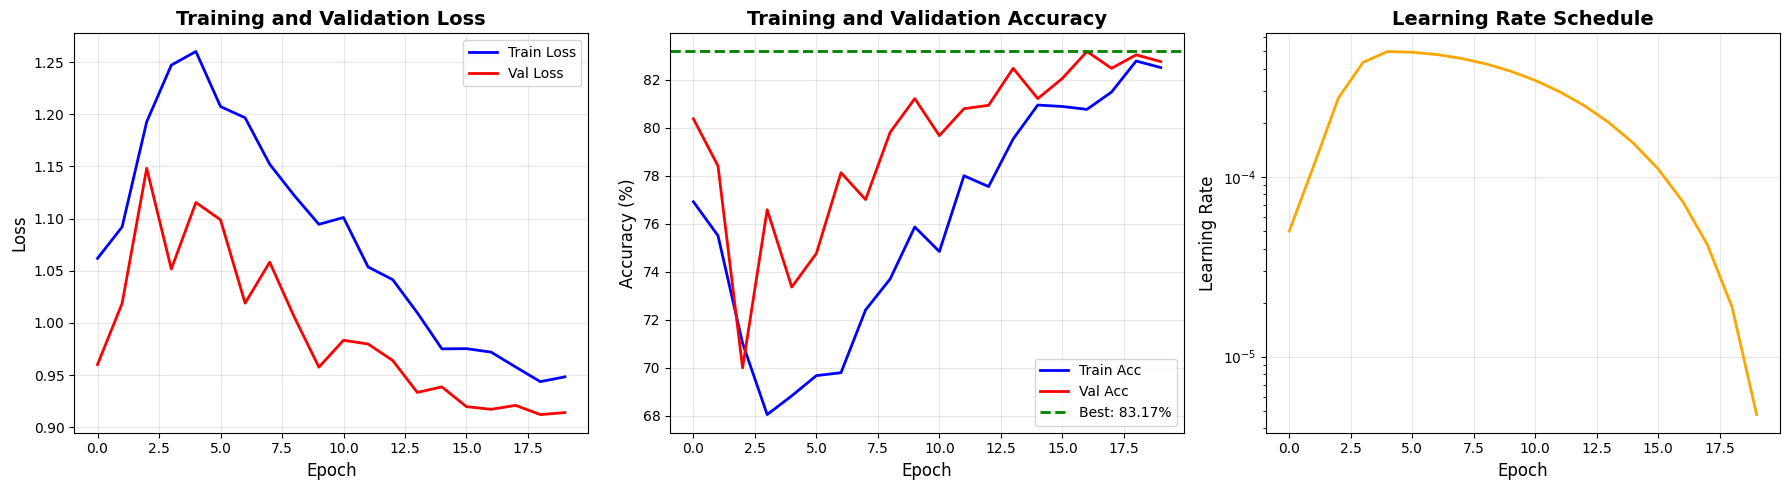

In [51]:
# Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss Plot
axes[0].plot(training_history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(training_history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy Plot
train_acc_percent = [acc * 100 for acc in training_history['train_acc']]
val_acc_percent = [acc * 100 for acc in training_history['val_acc']]
axes[1].plot(train_acc_percent, 'b-', label='Train Acc', linewidth=2)
axes[1].plot(val_acc_percent, 'r-', label='Val Acc', linewidth=2)
axes[1].axhline(y=best_val_accuracy * 100, color='g', linestyle='--',
                label=f'Best: {best_val_accuracy*100:.2f}%', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate Plot
axes[2].plot(training_history['learning_rates'], 'orange', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## Evaluation on test set

In [52]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate test accuracy
test_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\nTest Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 81.77%


In [53]:
# Cell 1: imports and helpers
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
from torchvision.transforms.functional import to_pil_image
from IPython.display import display
import math
import os

# plotting defaults
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['axes.grid'] = True

def tensor_to_cpu_img(tensor):
    """Convert a single CxHxW tensor (normalized) into a PIL image for display.
    Assumes tensor is normalized using dataset_mean/dataset_std used in training.
    We'll expect user to pass unnormalized if needed, otherwise we rely on inverse norm below."""
    if isinstance(tensor, torch.Tensor):
        t = tensor.detach().cpu().clamp(-5, 5)  # guard
        # If single image with channels first, turn to 0..1 approx
        t = (t - t.min()) / (t.max() - t.min() + 1e-8)
        return to_pil_image(t)
    raise ValueError("Expected a torch.Tensor")


## Get predictions and probabilities

### Subtask:
Add a cell to get the model's predictions and probabilities for a given data loader (e.g., the test loader).


**Reasoning**:
Set the model to evaluation mode and iterate through the test loader to get predictions and probabilities, storing them along with the true labels.



In [54]:
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1) # Get probabilities
        _, predicted = torch.max(outputs.data, 1) # Get predicted class

        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions and probabilities obtained successfully.")

Predictions and probabilities obtained successfully.


## Confusion matrix and metrics

### Subtask:
Add cells to compute and visualize the confusion matrix, and calculate per-class metrics like precision, recall, and F1-score.


**Reasoning**:
Compute and visualize the confusion matrix and calculate per-class metrics.



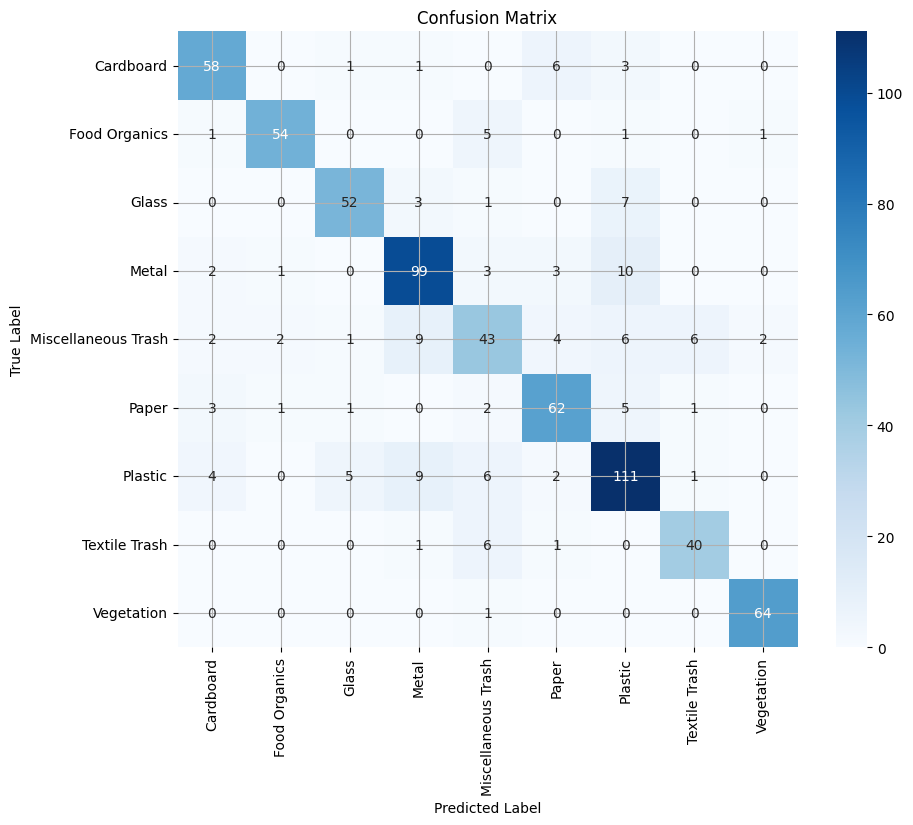


Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.83      0.84      0.83        69
      Food Organics       0.93      0.87      0.90        62
              Glass       0.87      0.83      0.85        63
              Metal       0.81      0.84      0.82       118
Miscellaneous Trash       0.64      0.57      0.61        75
              Paper       0.79      0.83      0.81        75
            Plastic       0.78      0.80      0.79       138
      Textile Trash       0.83      0.83      0.83        48
         Vegetation       0.96      0.98      0.97        65

           accuracy                           0.82       713
          macro avg       0.83      0.82      0.82       713
       weighted avg       0.82      0.82      0.82       713



In [55]:
# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate and print the classification report
print("\nClassification Report:")
# Get unique labels present in the test set
unique_labels = np.unique(all_labels)
# Select the corresponding target names
target_names_subset = [CLASS_NAMES[i] for i in unique_labels]
print(classification_report(all_labels, all_preds, labels=unique_labels, target_names=target_names_subset))